This script follows the capstone stage two black box optimisation challenge, this is the first attempt for week 1

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import os 
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import sys
from aima3 import learning
%matplotlib inline

import numpy as np
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as func
import sklearn 

import sys
from aima3 import learning
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as func
import sklearn 
from sklearn.model_selection import KFold
import random 
from numpy import random
import pandas as pd 
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#Use the following to plot SVMs
from mlxtend.plotting import plot_decision_regions #On terminal, install pip.install mlxtend

In [2]:

# Acquisition functions 
# UCB function 
def acquisition_UCB(beta, mean, stddev, candidates):

    ucb = mean + beta * stddev # compute UCB 
    best_index = np.argmax(ucb) # find the argument x of a(x) that maximises 

    # use index to find best candidate function

    

    return np.round(candidates[best_index],6)

def accquisition_expected_improvement(mu, sigma, f_best, xi=0.0):
    """
    Compute Expected Improvement.

    Parameters
    ----------
    mu : array
        Posterior mean
    sigma : array
        Posterior std
    f_best : float
        Best observed value so far
    xi : float
        Exploration parameter (small positive value)

    Returns
    -------
    EI : array
    """

    sigma = np.maximum(sigma, 1e-12)  # avoid division by zero

    improvement = mu - f_best - xi
    Z = improvement / sigma

    EI = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    EI[sigma < 1e-12] = 0.0

    return EI


def accquisition_prob_improve(mu, sigma, f_best, xi=0.01):
    """
    Probability of Improvement (PI) acquisition function.

    Parameters
    ----------
    mu : array-like
        Posterior mean from GP
    sigma : array-like
        Posterior standard deviation from GP
    f_best : float
        Best observed value so far
    xi : float
        Exploration parameter (encourages exploration)

    Returns
    -------
    PI : array
        Probability of improvement at each point
    """

    mu = np.asarray(mu)
    sigma = np.asarray(sigma)

    # avoid division by zero
    sigma = np.maximum(sigma, 1e-12)

    Z = (mu - f_best - xi) / sigma

    PI = norm.cdf(Z)

    # if sigma ~ 0 → no uncertainty → no improvement possible
    PI[sigma < 1e-12] = 0.0

    return PI



In [16]:
# Gaussian process surrogate models
# implement GPR with a RBF kernel 
def GPR_with_RBF_kernel_monte_carlo(rbf_lengthscale,
                        noise_assumption,
                        ins,outs,
                        sample_size,
                        in_cols):
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed') # user defined length scale 
    #kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-3, 1e3)) # letting GP learn the length scale of the data
    model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

    # normalise all dimensions 
    
   
    #fit data to GPR model 
    model.fit(ins,outs)



    # generate possible coordinate samples for acquisition function

    rng = np.random.default_rng(seed=42)

    sample_ins = rng.random((sample_size, in_cols))
    #print(sample_ins.shape)

    # above sample assumes the coords are between [0,1)

    post_mean, post_std = model.predict(sample_ins ,return_std=True)

    return post_mean, post_std, sample_ins

def GPR_with_RBF_kernel_grid_search(rbf_lengthscale,
                        noise_assumption,
                        ins,outs,
                        n_points,
                        ):
    
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed') # user defined length scale 
    #kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-3, 1e3)) # letting GP learn the length scale of the data
    model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

    # normalise all dimensions 
    
   
    #fit data to GPR model 
    model.fit(ins,outs)



    # generate possible coordinate samples for acquisition function

    x1 = np.linspace(0,1,n_points)
    x2 = np.linspace(0,1,n_points)

    X1, X2 = np.meshgrid(x1, x2)

    sample_ins = np.vstack([X1.ravel(), X2.ravel()]).T
    #print(sample_ins.shape)

    # above sample assumes the coords are between [0,1)

    post_mean, post_std = model.predict(sample_ins ,return_std=True)

    return post_mean, post_std, sample_ins


def GPR_with_learned_hyperparameters(
    ins,
    outs,
    sample_size,
    in_cols,
    initial_length_scale=0.5,
    initial_noise=1e-4,
    n_restarts=10
):
    # kernel = (
    #     ConstantKernel(1.0, (1e-3, 1e3))
    #     * RBF(length_scale=initial_length_scale, length_scale_bounds=(1e-3, 1e3))
    #     + WhiteKernel(noise_level=initial_noise, noise_level_bounds=(1e-8, 1e0))
    # )
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(length_scale=initial_length_scale, length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=initial_noise, noise_level_bounds=(1e-8, 1e0))
    )



    model = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=42
    )

    model.fit(ins, outs)

    rng = np.random.default_rng(seed=42)
    sample_ins = rng.random((sample_size, in_cols))

    post_mean, post_std = model.predict(sample_ins, return_std=True)

    return post_mean, post_std, sample_ins, model

def propose_points_from_learned_gp(ins, outs, sample_size, in_cols, Beta, Xi):
    post_mean, post_std, sample_ins, model = GPR_with_learned_hyperparameters(
        ins=ins,
        outs=outs,
        sample_size=sample_size,
        in_cols=in_cols,
        initial_length_scale=0.5,
        initial_noise=1e-4,
        n_restarts=10
    )

    f_best = np.max(outs)

    x_next_UCB = acquisition_UCB(Beta, post_mean, post_std, sample_ins)

    ei = accquisition_expected_improvement(post_mean, post_std, f_best)
    x_next_EI = sample_ins[np.argmax(ei)]

    pi = accquisition_prob_improve(post_mean, post_std, f_best, xi=Xi)
    x_next_PI = sample_ins[np.argmax(pi)]

    return {
        "UCB": np.round(x_next_UCB, 6),
        "EI": np.round(x_next_EI, 6),
        "PI": np.round(x_next_PI, 6),
        "model": model
    }




In [4]:
# selection functions and other analyses 

def check_unit_cube(X, tol=1e-12):
    """
    Per-dimension check of whether inputs lie in [0,1].
    """

    X = np.asarray(X)

    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)

    for i, (mn, mx) in enumerate(zip(mins, maxs)):
        status = (mn >= -tol) and (mx <= 1 + tol)

        print(f"Dim {i}: min={mn:.6f}, max={mx:.6f} -> "
              f"{'OK' if status else 'OUT OF RANGE'}")

    return np.all((mins >= -tol) & (maxs <= 1 + tol))

def compute_acquisition_consistency(results):
    """
    Compute consistency (max pairwise distance) for each noise level.

    Parameters
    ----------
    results : list of dict
        Each dict contains:
        {'noise': ..., 'UCB': ..., 'EI': ..., 'PI': ...}

    Returns
    -------
    summary : list of dict
        [{'noise': ..., 'consistency': ...}, ...]
    """

    summary = []

    for entry in results:
        x_ucb = np.asarray(entry['UCB'])
        x_ei  = np.asarray(entry['EI'])
        x_pi  = np.asarray(entry['PI'])

        # pairwise distances
        d_ue = np.linalg.norm(x_ucb - x_ei)
        d_up = np.linalg.norm(x_ucb - x_pi)
        d_ep = np.linalg.norm(x_ei - x_pi)

        d_max = max(d_ue, d_up, d_ep)

        summary.append({
            'noise': entry['noise'],
            'consistency': d_max
        })

    return summary

def compute_between_noise_distances(results, key):
    distances = []

    for i in range(len(results) - 1):
        x1 = np.asarray(results[i][key], dtype=float)
        x2 = np.asarray(results[i + 1][key], dtype=float)

        dist = np.linalg.norm(x2 - x1)
        distances.append(dist)

    return np.array(distances)  # ← FIX HERE

def select_noise_from_stability(results, key='UCB', tol=1e-6):
    """
    Select a noise level based on stability of the predicted next point.

    Strategy
    --------
    1. Compute distances between predicted points at consecutive noise levels.
    2. Mark transitions where the prediction does NOT change (distance < tol).
    3. Identify the longest consecutive region of stability.
    4. Choose the midpoint of this region as a representative noise level.

    Parameters
    ----------
    results : list of dict
        Each entry has the form:
        {'noise': ..., 'UCB': ..., 'EI': ..., 'PI': ...}

    key : str
        Which acquisition function to use ('UCB', 'EI', or 'PI').

    tol : float
        Tolerance for deciding if two points are "the same".
        If distance < tol → considered stable.

    Returns
    -------
    dict
        {
            'noise': selected noise value,
            'x_next': predicted next point at that noise,
            'index': index of selected noise in results
        }
    """

    # Step 1: compute distances between consecutive noise levels
    # distances[i] = || x(sigma_{i+1}) - x(sigma_i) ||
    distances = compute_between_noise_distances(results, key)

    # Step 2: convert distances into a boolean stability mask
    # True  → no change in predicted point (stable)
    # False → change occurred (instability / jump)
    stable = distances < tol

    # Step 3: find the longest consecutive "True" segment
    max_len = 0        # length of longest stable segment found so far
    best_start = 0     # starting index of that segment

    current_len = 0    # length of current segment being tracked
    current_start = 0  # start index of current segment

    for i, val in enumerate(stable):

        if val:
            # If entering a new stable segment, record where it starts
            if current_len == 0:
                current_start = i

            # Extend current stable segment
            current_len += 1

            # Update best segment if this one is longer
            if current_len > max_len:
                max_len = current_len
                best_start = current_start

        else:
            # Instability encountered → reset current segment
            current_len = 0

    # Step 4: choose midpoint of the longest stable segment
    # This avoids picking boundary values and gives a representative point
    best_index = best_start + max_len // 2

    # Step 5: return the corresponding noise and predicted next point
    return {
        'noise': results[best_index]['noise'],
        'x_next': results[best_index][key],
        'index': best_index
    }

def get_best_observed_input(ins, outs):
    idx = np.argmax(outs)
    return ins[idx]

def select_best_acquisition_from_candidates(x_ucb, x_ei, x_pi, best_input):
    """
    Select the acquisition function whose predicted point
    is closest to the previously observed best input.
    """

    best_input = np.asarray(best_input, dtype=float)

    d_ucb = np.linalg.norm(np.asarray(x_ucb) - best_input)
    d_ei  = np.linalg.norm(np.asarray(x_ei)  - best_input)
    d_pi  = np.linalg.norm(np.asarray(x_pi)  - best_input)

    distances = {
        "UCB": d_ucb,
        "EI": d_ei,
        "PI": d_pi
    }

    best_key = min(distances, key=distances.get)

    return {
        "selected_acquisition": best_key,
        "selected_point": {
            "UCB": x_ucb,
            "EI": x_ei,
            "PI": x_pi
        }[best_key],
        "distances": distances

    
    }





In [5]:
# unsupervised methods - some generated by chat gpt 


def conduct_PCA(
    observed_inputs,
    special_points=None,
    standardise=True,
    n_components=2
):
    """
    Perform PCA on the observed input space and project both the observed
    points and any additional special points into the same PCA space.

    Parameters
    ----------
    observed_inputs : array-like of shape (n_samples, n_features)
        The input points already observed by the optimisation procedure.

    special_points : dict or None, default=None
        Optional dictionary of named points to project using the same PCA map.
        Example:
            {
                "UCB": x_ucb,
                "EI": x_ei,
                "PI": x_pi
            }
        Each value should be a 1D array of shape (n_features,).

    standardise : bool, default=True
        If True, standardise each input dimension before PCA.
        This is usually a good idea unless all features are already on
        exactly comparable scales.

    n_components : int, default=2
        Number of principal components to retain.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "observed_projected": PCA coordinates of observed_inputs
        - "special_projected": dict of projected special points
        - "explained_variance_ratio": variance explained by each component
        - "pca_model": fitted PCA object
        - "scaler": fitted scaler or None
    """
    X_obs = np.asarray(observed_inputs)

    if X_obs.ndim != 2:
        raise ValueError("observed_inputs must be a 2D array of shape (n_samples, n_features)")

    if special_points is None:
        special_points = {}

    # Stack all points so scaling/PCA are fitted consistently
    all_points = [X_obs]
    special_names = []
    special_arrays = []

    for name, point in special_points.items():
        point = np.asarray(point)
        if point.ndim != 1:
            raise ValueError(f"Special point '{name}' must be a 1D array of shape (n_features,)")
        if point.shape[0] != X_obs.shape[1]:
            raise ValueError(
                f"Special point '{name}' has {point.shape[0]} features, "
                f"but observed_inputs has {X_obs.shape[1]}"
            )
        special_names.append(name)
        special_arrays.append(point.reshape(1, -1))
        all_points.append(point.reshape(1, -1))

    X_all = np.vstack(all_points)

    scaler = None
    if standardise:
        scaler = StandardScaler()
        X_all_scaled = scaler.fit_transform(X_all)
    else:
        X_all_scaled = X_all.copy()

    pca_model = PCA(n_components=n_components)
    X_all_projected = pca_model.fit_transform(X_all_scaled)

    n_obs = X_obs.shape[0]
    observed_projected = X_all_projected[:n_obs]

    special_projected = {}
    idx = n_obs
    for name in special_names:
        special_projected[name] = X_all_projected[idx]
        idx += 1

    results = {
        "observed_projected": observed_projected,
        "special_projected": special_projected,
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "pca_model": pca_model,
        "scaler": scaler
    }

    return results

def conduct_PCA_improved(
    observed_inputs,
    special_points=None,
    standardise=True,
    n_components=2
):
    """
    Perform PCA on the observed input space and project both the observed
    points and any additional special points into the same PCA space.

    Parameters
    ----------
    observed_inputs : array-like of shape (n_samples, n_features)
        The input points already observed by the optimisation procedure.

    special_points : dict or None, default=None
        Optional dictionary of named points to project using the same PCA map.
        Example:
            {
                "UCB": x_ucb,
                "EI": x_ei,
                "PI": x_pi
            }
        Each value should be a 1D array of shape (n_features,).

    standardise : bool, default=True
        If True, standardise each input dimension before PCA.

    n_components : int, default=2
        Number of principal components to retain.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "observed_projected": PCA coordinates of observed_inputs
        - "special_projected": dict of projected special points
        - "explained_variance_ratio": variance explained by each component
        - "principal_directions": PCA directions in feature space
        - "pca_model": fitted PCA object
        - "scaler": fitted scaler or None
    """
    X_obs = np.asarray(observed_inputs)

    if X_obs.ndim != 2:
        raise ValueError("observed_inputs must be a 2D array of shape (n_samples, n_features)")

    if special_points is None:
        special_points = {}

    n_features = X_obs.shape[1]

    for name, point in special_points.items():
        point = np.asarray(point)
        if point.ndim != 1:
            raise ValueError(f"Special point '{name}' must be a 1D array of shape (n_features,)")
        if point.shape[0] != n_features:
            raise ValueError(
                f"Special point '{name}' has {point.shape[0]} features, "
                f"but observed_inputs has {n_features}"
            )

    scaler = None
    if standardise:
        scaler = StandardScaler()
        X_obs_scaled = scaler.fit_transform(X_obs)
    else:
        X_obs_scaled = X_obs.copy()

    pca_model = PCA(n_components=n_components)
    observed_projected = pca_model.fit_transform(X_obs_scaled)

    special_projected = {}
    for name, point in special_points.items():
        point_2d = np.asarray(point).reshape(1, -1)

        if standardise:
            point_2d = scaler.transform(point_2d)

        special_projected[name] = pca_model.transform(point_2d)[0]

    results = {
        "observed_projected": observed_projected,
        "special_projected": special_projected,
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "principal_directions": pca_model.components_,   # shape (n_components, n_features)
        "pca_model": pca_model,
        "scaler": scaler
    }

    return results

def conduct_PCA_homemade(X,y,scaler): # written by me not chat gpt 

        # standardise the data 
        #scaler=StandardScaler() # mean 0 and sd 1 , treating all features equally 
        X_scaled= scaler.fit_transform(X)

        pca= PCA(n_components=2) # reduces the data to 2 components that explain most of the variance
        X_pca=pca.fit_transform(X_scaled)
        print(X_pca.shape)
        print(pca.components_)
        print("Explained variance:", pca.explained_variance_ratio_)
        print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))
       

        plt.figure(figsize=(8,6))
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y['Outputs'], cmap='coolwarm', edgecolor='k')
        plt.xlabel(f"Principal Component 1, { pca.explained_variance_ratio_[0]*100}%")
        plt.ylabel(f"Principal Component 2, { pca.explained_variance_ratio_[1]*100}%")
        plt.title("PCA Transformed Data")
        plt.colorbar(label="y")
        plt.show()

        return X_pca , pca #,scaler 

def plot_PCA_projection(
    pca_results,
    observed_outputs=None,
    title="PCA projection of input space"
):
    """
    Plot the 2D PCA projection of observed inputs and optional special points.

    Parameters
    ----------
    pca_results : dict
        Output from conduct_PCA().

    observed_outputs : array-like or None, default=None
        Optional values used to colour the observed points.

    title : str, default="PCA projection of input space"
        Plot title.
    """
    observed_projected = pca_results["observed_projected"]
    special_projected = pca_results["special_projected"]
    evr = pca_results["explained_variance_ratio"]

    plt.figure(figsize=(8, 6))

    if observed_outputs is None:
        plt.scatter(
            observed_projected[:, 0],
            observed_projected[:, 1],
            alpha=0.7,
            label="Observed inputs"
        )
    else:
        observed_outputs = np.asarray(observed_outputs).ravel()
        scatter = plt.scatter(
            observed_projected[:, 0],
            observed_projected[:, 1],
            c=observed_outputs,
            alpha=0.8
        )
        plt.colorbar(scatter, label="Observed output")

    for name, point in special_projected.items():
        plt.scatter(point[0], point[1], s=120, marker="X", label=name)
        plt.text(point[0], point[1], f" {name}", fontsize=10, va="center")

    plt.xlabel(f"PC1 ({100 * evr[0]:.1f}% variance)")
    plt.ylabel(f"PC2 ({100 * evr[1]:.1f}% variance)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def conduct_tSNE(
    observed_inputs,
    special_points=None,
    standardise=True,
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    random_state_in=42
):
    """
    Perform t-SNE on the observed input space, optionally including special
    points such as UCB/EI/PI proposals in the same embedding.

    Parameters
    ----------
    observed_inputs : array-like of shape (n_samples, n_features)
        Observed input points.

    special_points : dict or None, default=None
        Optional dictionary of named 1D points to include in the embedding.
        Example:
            {
                "UCB": x_ucb,
                "EI": x_ei,
                "PI": x_pi
            }

    standardise : bool, default=True
        Whether to standardise the features before t-SNE.

    n_components : int, default=2
        Number of embedding dimensions.

    perplexity : float, default=30
        t-SNE perplexity parameter. Must be smaller than the total number
        of points in the combined dataset.

    learning_rate : float or "auto", default="auto"
        t-SNE learning rate.

    max_iter : int, default=1000
        Number of optimisation iterations.

    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "observed_embedded": embedded coordinates of observed_inputs
        - "special_embedded": dict of embedded special points
        - "tsne_model": fitted TSNE instance
    """
    X_obs = np.asarray(observed_inputs)

    if X_obs.ndim != 2:
        raise ValueError("observed_inputs must be a 2D array of shape (n_samples, n_features)")

    if special_points is None:
        special_points = {}

    all_points = [X_obs]
    special_names = []

    for name, point in special_points.items():
        point = np.asarray(point)
        if point.ndim != 1:
            raise ValueError(f"Special point '{name}' must be a 1D array")
        if point.shape[0] != X_obs.shape[1]:
            raise ValueError(
                f"Special point '{name}' has {point.shape[0]} features, "
                f"but observed_inputs has {X_obs.shape[1]}"
            )
        all_points.append(point.reshape(1, -1))
        special_names.append(name)

    X_all = np.vstack(all_points)

    if perplexity >= X_all.shape[0]:
        raise ValueError(
            f"perplexity={perplexity} must be smaller than the total number "
            f"of points={X_all.shape[0]}"
        )

    if standardise:
        scaler = StandardScaler()
        X_all = scaler.fit_transform(X_all)

    tsne_model = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        init="pca",
        random_state=random_state_in
    )

    X_all_embedded = tsne_model.fit_transform(X_all)

    n_obs = X_obs.shape[0]
    observed_embedded = X_all_embedded[:n_obs]

    special_embedded = {}
    idx = n_obs
    for name in special_names:
        special_embedded[name] = X_all_embedded[idx]
        idx += 1

    results = {
        "observed_embedded": observed_embedded,
        "special_embedded": special_embedded,
        "tsne_model": tsne_model
    }

    return results   

def plot_tSNE_projection(
        
    tsne_results,
    observed_outputs=None,
    title="t-SNE projection of input space"
):
    """
    Plot the 2D t-SNE embedding of observed inputs and optional special points.

    Parameters
    ----------
    tsne_results : dict
        Output from conduct_tSNE().

    observed_outputs : array-like or None, default=None
        Optional values used to colour observed points.

    title : str, default="t-SNE projection of input space"
        Plot title.
    """
    observed_embedded = tsne_results["observed_embedded"]
    special_embedded = tsne_results["special_embedded"]

    plt.figure(figsize=(8, 6))

    if observed_outputs is None:
        plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            alpha=0.7,
            label="Observed inputs"
        )
    else:
        observed_outputs = np.asarray(observed_outputs).ravel()
        scatter = plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            c=observed_outputs,
            alpha=0.8
        )
        plt.colorbar(scatter, label="Observed output")

    for name, point in special_embedded.items():
        plt.scatter(point[0], point[1], s=140, marker="X", label=name,alpha=0.05)
        plt.text(point[0], point[1], f" {name}", fontsize=10, va="center")

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_tSNE_projection_monte_carlo_seeds(
        
    tsne_results,
    observed_outputs=None,
    title="t-SNE projection of input space"
):
    """
    Plot the 2D t-SNE embedding of observed inputs and optional special points.

    Parameters
    ----------
    tsne_results : dict
        Output from conduct_tSNE().

    observed_outputs : array-like or None, default=None
        Optional values used to colour observed points.

    title : str, default="t-SNE projection of input space"
        Plot title.
    """
    observed_embedded = tsne_results["observed_embedded"]
    special_embedded = tsne_results["special_embedded"]

    # plt.figure(figsize=(8, 6))

    if observed_outputs is None:
        plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            alpha=0.7,
            label="Observed inputs"
        )
    else:
        observed_outputs = np.asarray(observed_outputs).ravel()
        scatter = plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            c=observed_outputs,
            alpha=0.8
        )
        # plt.colorbar(scatter, label="Observed output")

    # for name, point in special_embedded.items():
    #     plt.scatter(point[0], point[1], s=140, marker="X", label=name,alpha=0.05)
    #     plt.text(point[0], point[1], f" {name}", fontsize=10, va="center")

    # plt.xlabel("t-SNE dimension 1")
    # plt.ylabel("t-SNE dimension 2")
    # plt.title(title)
    # plt.legend()
    # plt.tight_layout()
    # plt.show()


In [6]:

# neural netowkrs 
def monte_carlo_sample_from_neural_net(sample_size,in_cols,model):
        rng = np.random.default_rng(seed=42)

        sample_ins = rng.random((sample_size, in_cols))

        sample_ins_torch= torch.tensor(sample_ins,dtype=torch.float32)
        post_mean = model(sample_ins_torch)
        
        return  post_mean,sample_ins


def simple_neural_network(ins,outs,sample_size, learn_rate):
        # 1 hidden layer 

        print(ins.shape)
        in_cols=ins.shape[1]
        # create input tensor from ins of function 
        X = torch.tensor(ins,dtype=torch.float32)#Use numpy commands – example input to Layer 2
        y= torch.tensor(outs,dtype=torch.float32)

        model=nn.Sequential(
            nn.Linear(ins.shape[1],ins.shape[1]), # mapping 13x 2 inputs to 13x2 outputs 
            nn.ReLU(), # applying rectified linear unit activation function 
            nn.Linear(ins.shape[1],1) # mapping the 13x2 inputs to 13x1 outputs 
        )


        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=learn_rate) # stochastic gradient descent 

        num_epochs=20000

        for epoch in range(num_epochs):
            # Forward pass: predictions from current model parameters
            y_pred = model(X)

            # Compute loss
            loss = criterion(y_pred, y)

            # Clear old gradients
            optimizer.zero_grad()

            # Backward pass: compute gradients of loss wrt parameters
            loss.backward()

            # Gradient descent step
            optimizer.step()

            # Print progress occasionally
            # if epoch % 2000 == 0:
            #     print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

        print(f"Epoch {epoch}, final Loss = {loss.item():.6f}")


        
            

        post_mean,sample_ins=monte_carlo_sample_from_neural_net(sample_size,in_cols,model)
        # max post mean evaluation 
        max_post_mmean_idx=np.argmax(post_mean.detach().numpy())
        reccomended_point_from_neual_net=sample_ins[max_post_mmean_idx]
        #print("reccomended_point_from_neual_net",reccomended_point_from_neual_net)

        return reccomended_point_from_neual_net


def simple_neural_net_w_5_cross_fold_validation(ins,outs,sample_size,learn_rate):
    in_cols=ins.shape[1]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_val_losses=[]
    for train_idx, val_idx in kf.split(ins):
        X_train = torch.tensor(ins[train_idx], dtype=torch.float32)
        y_train = torch.tensor(outs[train_idx], dtype=torch.float32).view(-1, 1)

        X_val = torch.tensor(ins[val_idx], dtype=torch.float32)
        y_val = torch.tensor(outs[val_idx], dtype=torch.float32).view(-1, 1)


        model=nn.Sequential(
            nn.Linear(ins.shape[1],ins.shape[1]), # mapping 13x 2 inputs to 13x2 outputs 
            nn.ReLU(), # applying rectified linear unit activation function 
            nn.Linear(ins.shape[1],1) # mapping the 13x2 inputs to 13x1 outputs 
        )


        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=learn_rate) # stochastic gradient descent 

        num_epochs=10000

        for epoch in range(num_epochs):
            # Forward pass: predictions from current model parameters
            y_pred = model(X_train)

            # Compute loss
            loss = criterion(y_pred, y_train)

            # Clear old gradients
            optimizer.zero_grad()

            # Backward pass: compute gradients of loss wrt parameters
            loss.backward()

            # Gradient descent step
            optimizer.step()
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, y_val)

            # Print progress occasionally
            # if epoch % 2000 == 0:
            #     print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

            fold_val_losses.append(val_loss.item())



    mean_val_loss = np.mean(fold_val_losses)
    print("Mean CV loss:", mean_val_loss)

    post_mean,sample_ins=monte_carlo_sample_from_neural_net(sample_size,in_cols,model)
    # max post mean evaluation 
    max_post_mmean_idx=np.argmax(post_mean.detach().numpy())
    reccomended_point_from_neual_net=sample_ins[max_post_mmean_idx]
    print("reccomended_point_from_neual_net",reccomended_point_from_neual_net)

    return mean_val_loss ,reccomended_point_from_neual_net

Need to take the old data and the new inputs and outputs. Can join them together to get the new data set.


In [7]:
# simply paste new inputs below for the next week. 

new_outs=[np.float64(2.3707126345541754e-28), np.float64(0.5345949141078546), np.float64(-0.021303981597683014), np.float64(0.3125916105188442), np.float64(16822.325905059733), np.float64(-0.583568282382558), np.float64(0.4811200949987704), np.float64(9.7054804972316)]
for x in range(1,9):
    print("function output:", new_outs[x-1])



new_inputs=[np.array([0.772433, 0.767114]), 
            np.array([0.682487, 0.886304]), 
            np.array([0.384628, 0.437626, 0.452597]), 
            np.array([0.404558, 0.388015, 0.391467, 0.426452]), 
            np.array([0.920526, 1.089698, 0.540378, 1.339337]), 
            np.array([0.564118, 0.543044, 0.545076, 0.75768 , 0.227387]), 
            np.array([0.00358 , 0.569264, 0.351724, 0.304343, 0.559632, 0.82176 ]), 
            np.array([0.009136, 0.029457, 0.227666, 0.424728, 0.406422, 0.522447, 0.399105, 0.746412])]




def join_new_data_to_old(new_outs,new_inputs,data_file,new_file_deposit_path):
    # need to join the new y output 
    for i in range(1,9):
        ins=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/{data_file}/function_{i}/inputs.npy")
        outs=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/{data_file}/function_{i}/outputs.npy")
        
        
        #add row index for concatenation of the new inputs 
        new_ins_concat=np.reshape(new_inputs[i-1],(1,new_inputs[i-1].shape[0])) 
        # make single output into array for concat 
        new_outs_concat=np.array([new_outs[i-1]])
        


        new_input_arr=np.concatenate((ins,new_ins_concat),axis=0)
        print(new_input_arr.shape)
        new_output_arr=np.concatenate((outs,new_outs_concat),axis=0)
        print(new_output_arr.shape)

        print(os.getcwd())
        
        os.mkdir(f'{new_file_deposit_path}/function_{i}')
        np.save( f'{new_file_deposit_path}/function_{i}/inputs.npy',new_input_arr)
        np.save( f'{new_file_deposit_path}/function_{i}/outputs.npy',new_output_arr)





data_file='week_6/week_6_data'  
new_file_deposit_path='week_7_data'
join_new_data_to_old(new_outs,new_inputs,data_file,new_file_deposit_path)



function output: 2.3707126345541754e-28
function output: 0.5345949141078546
function output: -0.021303981597683014
function output: 0.3125916105188442
function output: 16822.325905059733
function output: -0.583568282382558
function output: 0.4811200949987704
function output: 9.7054804972316
(16, 2)
(16,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7
(16, 2)
(16,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7
(21, 3)
(21,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7
(36, 4)
(36,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7
(26, 4)
(26,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7
(26, 5)
(26,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7
(36, 6)
(36,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7
(46, 8)
(46,)
/Users/luke_dev/Documents/ML_AI_imperial_course_co

(16,)


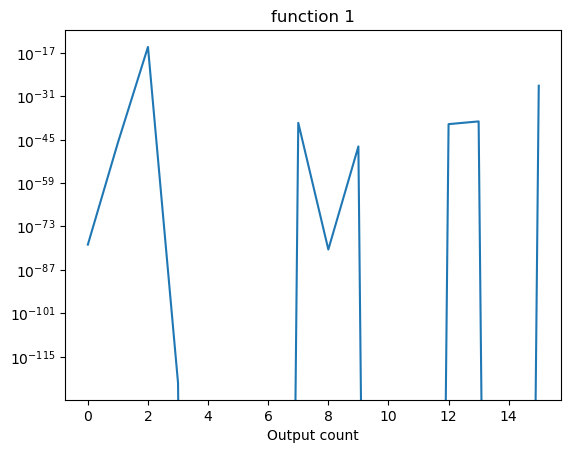

[[3.19403889e-01 7.62959374e-01]
 [5.74329215e-01 8.79898105e-01]
 [7.31023631e-01 7.32999876e-01]
 [8.40353417e-01 2.64731614e-01]
 [6.50114060e-01 6.81526352e-01]
 [4.10437137e-01 1.47554299e-01]
 [3.12691157e-01 7.87227779e-02]
 [6.83418169e-01 8.61057464e-01]
 [8.25072518e-02 4.03487506e-01]
 [8.83889829e-01 5.82253974e-01]
 [4.45000000e-03 9.94344000e-01]
 [9.99235000e-01 2.98000000e-04]
 [7.73956000e-01 4.38878000e-01]
 [6.83880000e-01 8.59533000e-01]
 [8.19804000e-01 7.02559000e-01]
 [7.72433000e-01 7.67114000e-01]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  0.00000000e+000  0.00000000e+000
  9.65622297e-041  7.35194636e-040 -2.35730938e-030  2.37071263e-028]


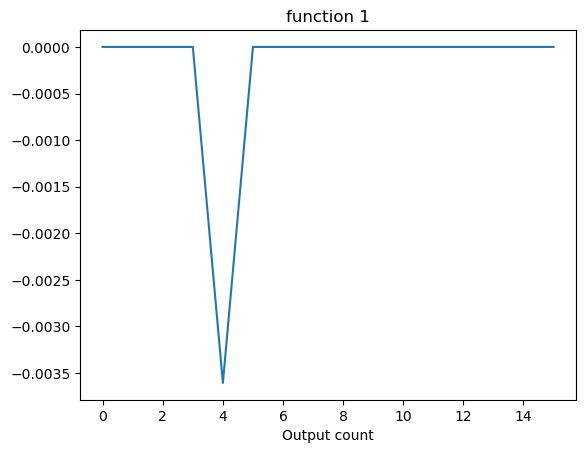

(16,)


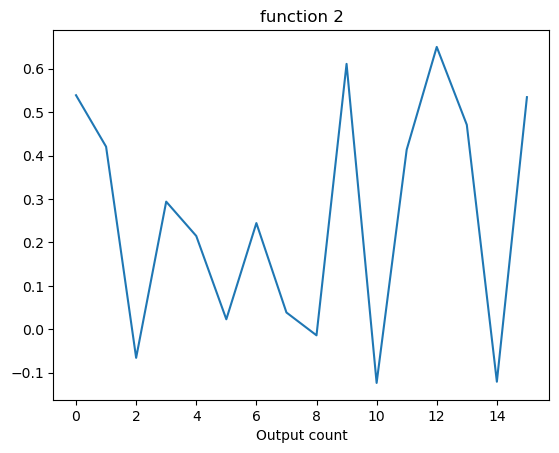

(16,)


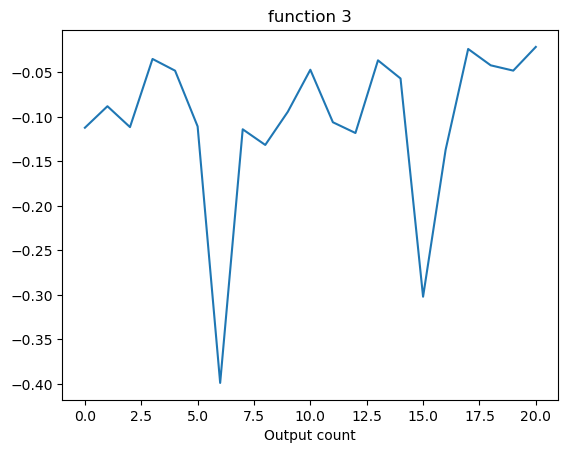

(16,)


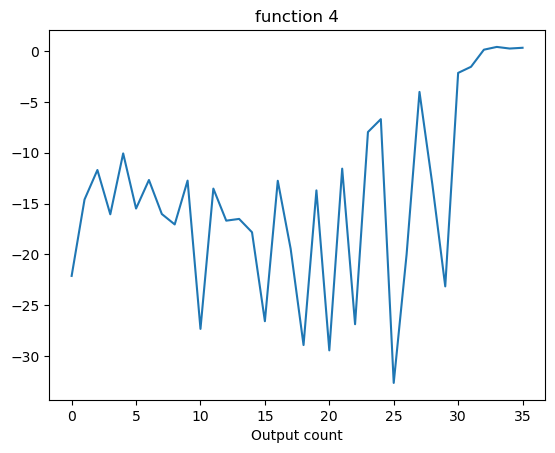

(16,)


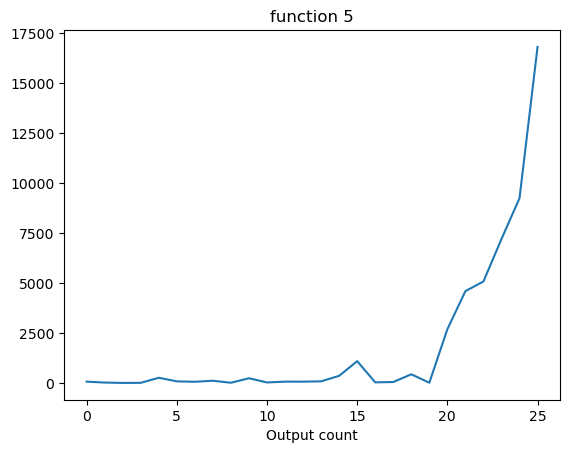

(16,)


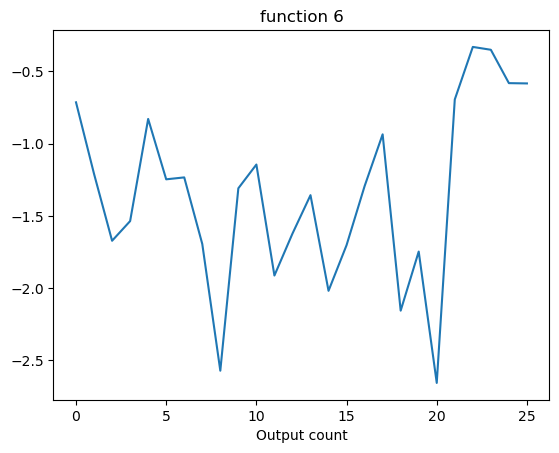

(16,)


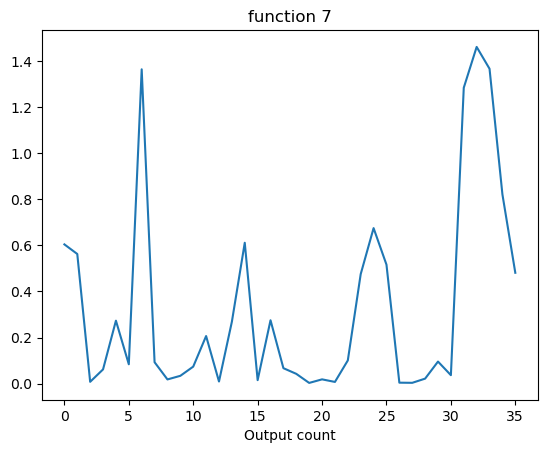

(16,)


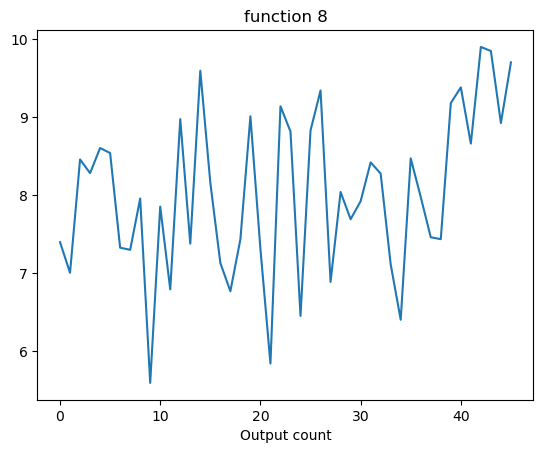

In [10]:
# visualise data so far
for k in range(1,9):
    ins=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7/week_7_data/function_{k}/inputs.npy")
    #print(ins)
    outs=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7/week_7_data/function_{k}/outputs.npy")
    print(outs_raw.shape)
    

    #ins=scaler.fit_transform(ins_raw, y=outs_raw)

    if k==1:
        plt.plot(outs)
        plt.title(f"function {k}")
        plt.xlabel("Output count")
        plt.yscale('log')

        plt.show()
        print(ins)
        print(outs)


    
    plt.plot(outs)
    plt.title(f"function {k}")
    plt.xlabel("Output count")
    plt.show()



## Gaussian process hyperparameter learning via log marginal likelihood

In this notebook, I fit a separate Gaussian process (GP) surrogate model to each black-box objective using the current observed input-output pairs.  
The role of the GP is to provide, for any candidate input \(\mathbf{x}\), both

- a **posterior mean** \(\mu(\mathbf{x})\), which estimates the objective value, and
- a **posterior standard deviation** \(\sigma(\mathbf{x})\), which quantifies uncertainty.

This is useful in Bayesian black-box optimisation because the next query should not be chosen only from currently promising regions, but also from regions where the model remains uncertain.

Unlike my earlier implementation, I no longer manually sweep over assumed noise values. Instead, the GP learns its kernel hyperparameters directly from the data by maximising the **log marginal likelihood** during fitting.

### Input preprocessing

Before fitting the GP, the input coordinates are scaled to the unit hypercube using a min-max transform.  
If the raw input vector is \(\mathbf{x} = (x_1,\dots,x_d)\), the scaled coordinate in each dimension is

$$
x_j^{\mathrm{scaled}}
=
\frac{x_j - x_j^{\min}}{x_j^{\max} - x_j^{\min}},
\qquad j=1,\dots,d.
$$

This places all input dimensions on a comparable scale before fitting the kernel.

In the current version of the notebook, the outputs are ultimately passed to the GP in their raw form,

$$
y_i = f(\mathbf{x}_i),
$$

although I experimented with output scaling during development.

### Gaussian process model

Given observed inputs

$$
X = \{\mathbf{x}_1,\dots,\mathbf{x}_n\},
$$

and observed outputs

$$
\mathbf{y} = (y_1,\dots,y_n)^\top,
$$

the latent function is modelled as

$$
f(\mathbf{x}) \sim \mathcal{GP}\!\left(0,\,k(\mathbf{x},\mathbf{x}')\right).
$$

The kernel used in the code is

$$
k(\mathbf{x},\mathbf{x}')
=
\sigma_f^2
\exp\!\left(
-\frac{\|\mathbf{x}-\mathbf{x}'\|^2}{2\ell^2}
\right)
+
\sigma_n^2 \delta_{\mathbf{x},\mathbf{x}'},
$$

which corresponds to a product of a constant kernel and an RBF kernel, plus a white-noise term.  
Here,

- \(\sigma_f^2\) is the signal variance,
- \(\ell\) is the RBF length scale,
- \(\sigma_n^2\) is the observation noise variance,
- \(\delta_{\mathbf{x},\mathbf{x}'}\) is the Kronecker delta.

In the notebook this is implemented as

$$
k
=
\text{ConstantKernel}
\times
\text{RBF}
+
\text{WhiteKernel}.
$$

So the hyperparameter vector is

$$
\theta = (\sigma_f^2,\ell,\sigma_n^2).
$$

### Log marginal likelihood optimisation

The covariance matrix over the observed inputs is

$$
K_\theta(X,X)
=
\bigl[k(\mathbf{x}_i,\mathbf{x}_j)\bigr]_{i,j=1}^n.
$$

The hyperparameters are selected by maximising the GP log marginal likelihood

$$
\log p(\mathbf{y}\mid X,\theta)
=
-\frac{1}{2}\mathbf{y}^\top K_\theta^{-1}\mathbf{y}
-\frac{1}{2}\log|K_\theta|
-\frac{n}{2}\log(2\pi).
$$

This objective balances three competing effects:

- **data fit**, through the quadratic term  
  $$
  -\frac{1}{2}\mathbf{y}^\top K_\theta^{-1}\mathbf{y},
  $$
- **model complexity**, through the log-determinant penalty  
  $$
  -\frac{1}{2}\log|K_\theta|,
  $$
- **normalisation of the Gaussian model**, through  
  $$
  -\frac{n}{2}\log(2\pi).
  $$

In practice, this optimisation is handled internally by `GaussianProcessRegressor.fit(...)`, with `n_restarts_optimizer=10` to reduce the risk of converging to a poor local optimum.

### GP posterior prediction

After fitting, the GP is evaluated on a large Monte Carlo candidate set of inputs sampled uniformly from the unit hypercube.  
If \(X_*\) denotes the candidate set, then the GP posterior at \(X_*\) is Gaussian with mean

$$
\mu(X_*)
=
K(X_*,X)\,K(X,X)^{-1}\mathbf{y},
$$

and covariance

$$
\Sigma(X_*)
=
K(X_*,X_*)
-
K(X_*,X)\,K(X,X)^{-1}K(X,X_*).
$$

The posterior standard deviation used in the acquisition functions is obtained from the diagonal entries,

$$
\sigma(\mathbf{x})
=
\sqrt{\operatorname{Var}(f(\mathbf{x})\mid X,\mathbf{y})}.
$$

So each candidate point receives both a predicted objective value and an uncertainty estimate.

### Acquisition functions used

I then evaluate three standard acquisition functions on the Monte Carlo candidate set.

#### Upper Confidence Bound (UCB)

The UCB score is

$$
a_{\mathrm{UCB}}(\mathbf{x})
=
\mu(\mathbf{x}) + \beta\,\sigma(\mathbf{x}),
$$

where \(\beta > 0\) controls the exploration-exploitation trade-off.  
Larger \(\beta\) places more weight on uncertain regions.

#### Expected Improvement (EI)

Let

$$
f_{\mathrm{best}} = \max_{1\leq i\leq n} y_i
$$

be the best observed objective value so far.  
Then the improvement at \(\mathbf{x}\) is measured relative to \(f_{\mathrm{best}} + \xi\), where \(\xi \ge 0\) is an exploration parameter. Define

$$
Z(\mathbf{x})
=
\frac{\mu(\mathbf{x}) - f_{\mathrm{best}} - \xi}{\sigma(\mathbf{x})}.
$$

The expected improvement is

$$
a_{\mathrm{EI}}(\mathbf{x})
=
\bigl(\mu(\mathbf{x}) - f_{\mathrm{best}} - \xi\bigr)\Phi(Z(\mathbf{x}))
+
\sigma(\mathbf{x})\phi(Z(\mathbf{x})),
$$

where \(\Phi\) and \(\phi\) are the standard normal CDF and PDF respectively.

#### Probability of Improvement (PI)

Using the same \(Z(\mathbf{x})\), the probability of improvement is

$$
a_{\mathrm{PI}}(\mathbf{x})
=
\Phi(Z(\mathbf{x})).
$$

This measures only the probability of beating the current best value by at least \(\xi\), not the expected size of the improvement.

### Additional structure learning in the loop

After fitting the GP, I also analyse the observed input cloud using principal component analysis (PCA).  
If \(X\) denotes the scaled input matrix, PCA projects it onto a lower-dimensional representation,

$$
X_{\mathrm{PCA}} = XW,
$$

where the columns of \(W\) are the leading principal directions.  
I currently retain the first two principal components to visualise the geometry of the sampled region.

I then label the top-performing observations by thresholding the outputs.  
If the cutoff value is denoted by \(y_{\mathrm{cutoff}}\), the binary labels are

$$
\ell_i
=
\begin{cases}
1, & y_i \ge y_{\mathrm{cutoff}},\\[4pt]
0, & y_i < y_{\mathrm{cutoff}}.
\end{cases}
$$

These labels are used to train an RBF-kernel support vector machine (SVM) in the 2D PCA space.  
The purpose of this step is not to replace the GP, but to identify a coarse “promising region” in the reduced space. I then sample points from the SVM-positive region, map them back to the original scaled input space via the inverse PCA transform, and evaluate the GP posterior and acquisition functions there.

So the full workflow is:

1. Load the current input-output data for one black-box function.
2. Scale the inputs to \([0,1]^d\).
3. Fit a GP with learnable kernel hyperparameters by maximising the log marginal likelihood.
4. Generate a large Monte Carlo candidate set and evaluate the GP posterior mean and uncertainty.
5. Use PCA to visualise the observed inputs in two dimensions.
6. Label the best-performing observations and fit an SVM to identify a candidate success region in PCA space.
7. Sample from that region, map the points back to the original input space, and evaluate the GP there.
8. Apply UCB, EI, and PI to propose candidate next points.

### Difference from the earlier version

Previously, I used an outer loop to manually vary the assumed GP noise level and then selected a candidate based on that sweep.  
That manual tuning has now been removed. The current approach instead lets the GP learn its own signal variance, length scale, and noise level directly from the observed data. This gives a single learned probabilistic model for each black-box function before the acquisition functions are applied.

Overall, the method combines three ideas:

- a **Gaussian process** to model the black-box objective and quantify uncertainty,
- **acquisition functions** to trade off exploration and exploitation,
- **PCA + SVM filtering** to focus the search on regions that appear structurally promising from the observed data.

In [ ]:
for k in range(1,9): #9
    
    ins_raw = np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_6/week_6_data/function_{k}/inputs.npy"
    )
    outs_raw=np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_6/week_6_data/function_{k}/outputs.npy"
    )

    scaler=StandardScaler()

    ins=scaler.transform(ins_raw)
    outs=scaler.transform(outs_raw)

    plt.plot()


(16,)
scaled outs  [ 0.25819889  0.25819889  0.25819889  0.25819889 -3.87298335  0.25819889
  0.25819889  0.25819889  0.25819889  0.25819889  0.25819889  0.25819889
  0.25819889  0.25819889  0.25819889  0.25819889]
raw outs [ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  0.00000000e+000  0.00000000e+000
  9.65622297e-041  7.35194636e-040 -2.35730938e-030  2.37071263e-028]


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 1 analysis
(16, 2)
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Explained variance: [0.56960437 0.43039563]
Cumulative: [0.56960437 1.        ]


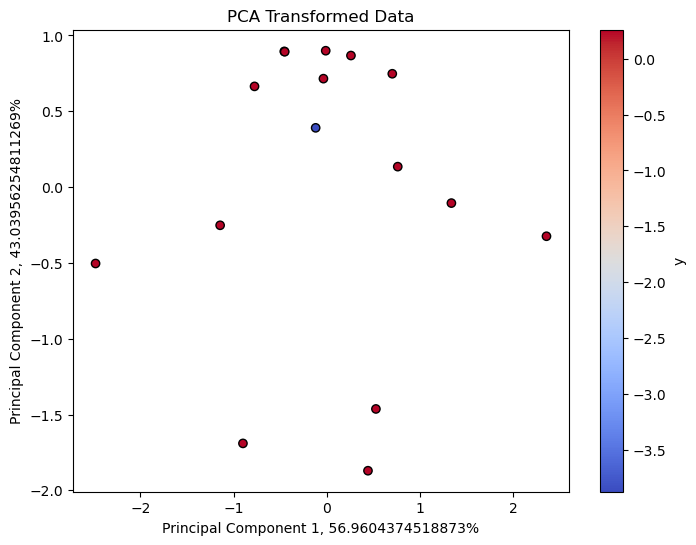

cutoff for high values 0.2581988897471022
[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


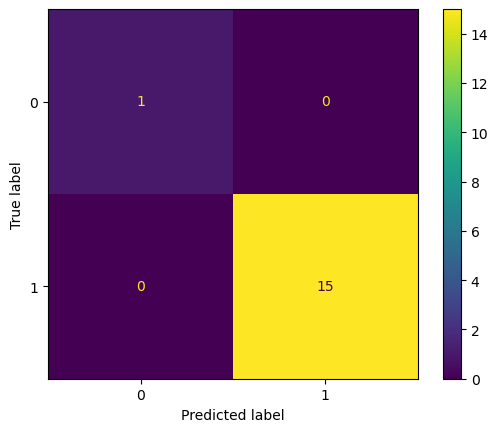

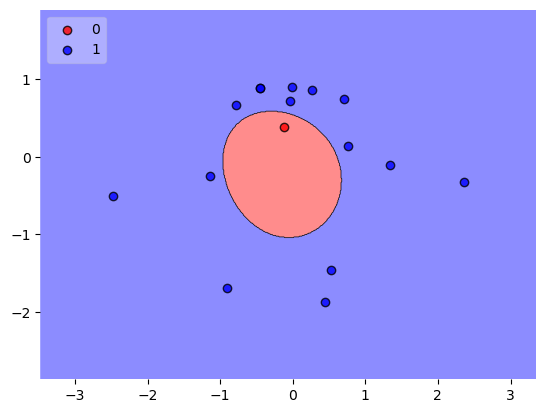

{'UCB': array([[0.83296325, 0.35439419]]), 'EI': array([[0.79343593, 0.35562025]]), 'PI': array([[0.74084816, 0.73530174]])}
previous point tried  [0.772433 0.767114]
previous output 2.3707126345541754e-28, max output 7.710875114502849e-16
(16,)
scaled outs  [ 1.06866839  0.61792759 -1.23288609  0.13603555 -0.16479514 -0.8951283
 -0.05191061 -0.83557965 -1.03583284  1.34354061 -1.45293822  0.5915536
  1.49215575  0.80970555 -1.44243088  1.0519147 ]
raw outs [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.12343145  0.41365778
  0.6502465   0.47096643 -0.12067117  0.53459491]


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 2 analysis
(16, 2)
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
Explained variance: [0.61382201 0.38617799]
Cumulative: [0.61382201 1.        ]


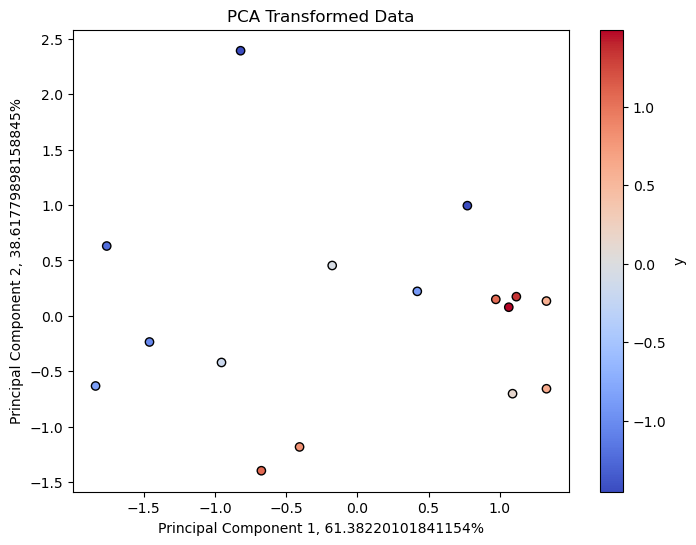

cutoff for high values 1.0686683893932192
[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0]


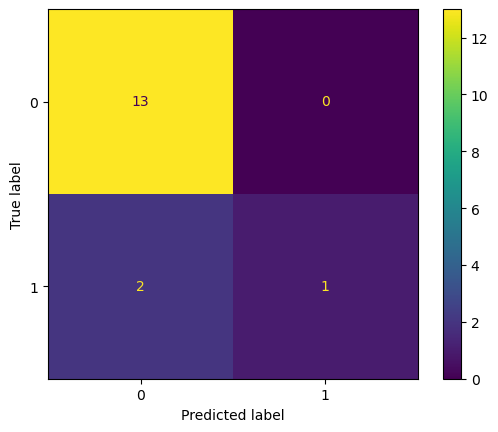

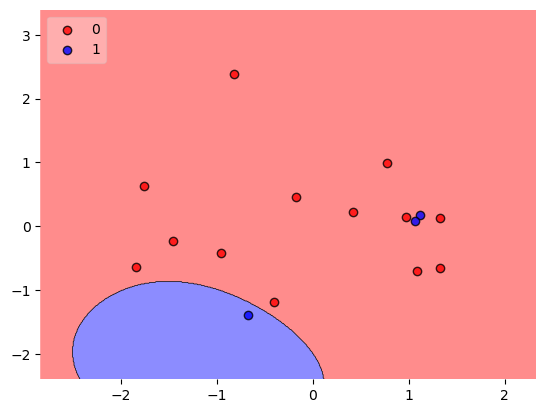

{'UCB': array([[0.61745347, 0.15641682]]), 'EI': array([[0.6008701, 0.0363537]]), 'PI': array([[0.6067454 , 0.14799369]])}
previous point tried  [0.682487 0.886304]
previous output 0.5345949141078546, max output 0.6502465023339654
(21,)
scaled outs  [-0.09250718  0.1783144  -0.08457572  0.77386403  0.62620539 -0.07567803
 -3.30751741 -0.11208303 -0.30928703  0.10851428  0.63808979 -0.02348654
 -0.15893713  0.75657274  0.52811075 -2.22126721 -0.3703847   0.89975035
  0.69374483  0.62700975  0.92554767]
raw outs [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.30202375 -0.13691098 -0.0236053
 -0.04198255 -0.04793583 -0.02130398]


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 3 analysis
(21, 2)
[[ 0.06157226  0.71138407 -0.7001011 ]
 [ 0.96942793  0.12430066  0.21156284]]
Explained variance: [0.50824218 0.34375359]
Cumulative: [0.50824218 0.85199577]


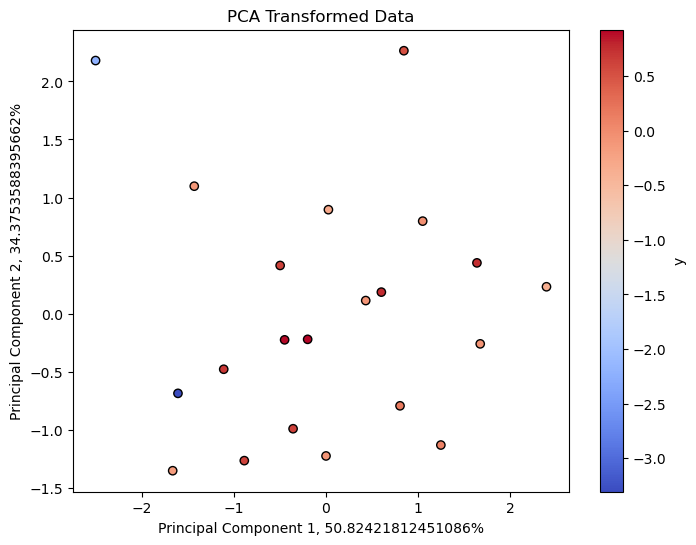

cutoff for high values 0.756572736539785
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1]


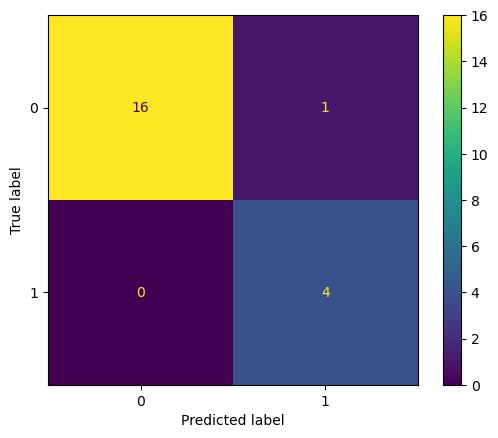

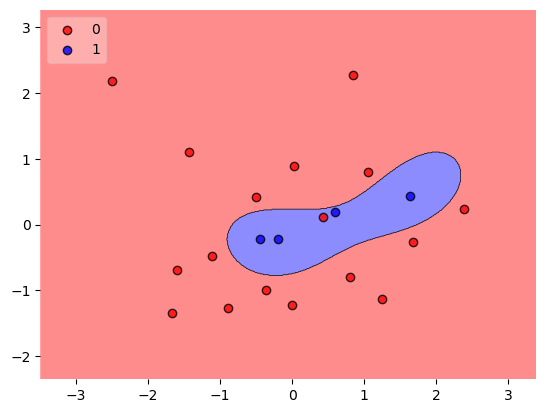

{'UCB': array([[0.46205873, 0.49662745, 0.41516211]]), 'EI': array([[0.45711867, 0.49500637, 0.41511464]]), 'PI': array([[0.43124806, 0.47605146, 0.42653287]])}
previous point tried  [0.384628 0.437626 0.452597]
previous output -0.021303981597683014, max output -0.021303981597683014
(36,)
scaled outs  [-0.8552858  -0.01812057  0.30544944 -0.18008807  0.48725968 -0.11689188
  0.19596483 -0.1770363  -0.2911024   0.18926462 -1.4360918   0.10162331
 -0.24982684 -0.23065031 -0.37683471 -1.35194187  0.18741806 -0.55789322
 -1.61305967  0.08209645 -1.67147559  0.32041431 -1.38494782  0.7217695
  0.86280674 -2.02817859 -0.61899928  1.16129409  0.14677385 -0.97027816
  1.36956537  1.43672838  1.62409493  1.65440342  1.63669503  1.64508089]
raw outs [-22.10828779 -14.60139663 -11.69993246 -16.05376511 -10.06963343
 -15.48708254 -12.68168498 -16.02639977 -17.04923465 -12.74176599
 -27.31639636 -13.52764887 -16.6791152  -16.50715856 -17.81799934
 -26.56182083 -12.75832422 -19.44155762 -28.90327367

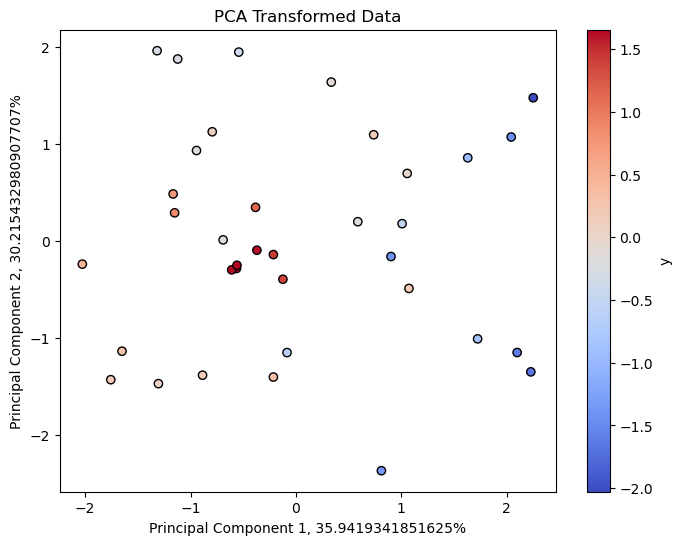

cutoff for high values 1.4367283774218096
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]


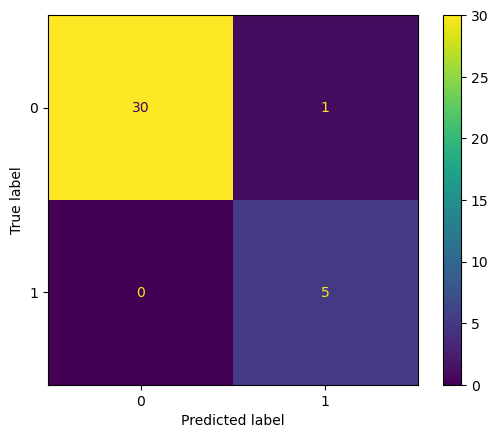

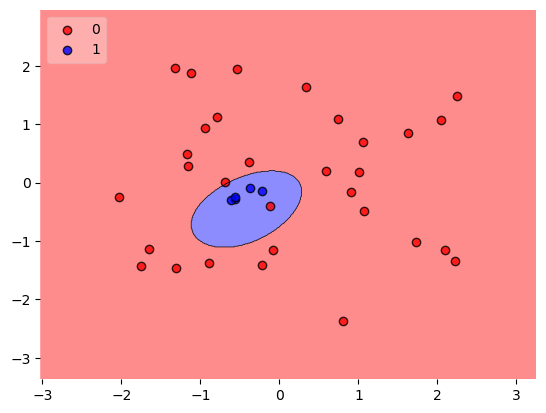

{'UCB': array([[0.40327594, 0.37633099, 0.4085803 , 0.39654283]]), 'EI': array([[0.40327594, 0.37633099, 0.4085803 , 0.39654283]]), 'PI': array([[0.40275498, 0.37009615, 0.41524878, 0.3891125 ]])}
previous point tried  [0.404558 0.388015 0.391467 0.426452]
previous output 0.3125916105188442, max output 0.3961870700715946
(26,)
scaled outs  [-0.46955207 -0.4815405  -0.48626615 -0.48520143 -0.41916677 -0.465917
 -0.4713375  -0.45782699 -0.48399664 -0.42570033 -0.47994999 -0.46955812
 -0.46980324 -0.46558061 -0.39385128 -0.20339264 -0.47879545 -0.47455661
 -0.37415571 -0.48370452  0.21200772  0.70768229  0.83331861  1.38600734
  1.91642834  3.88440926]
raw outs [6.44434399e+01 1.83013796e+01 1.12939795e-01 4.21089813e+00
 2.58370525e+02 7.84343889e+01 5.75715369e+01 1.09571876e+02
 8.84799176e+00 2.33223610e+02 2.44230883e+01 6.44201468e+01
 6.34767158e+01 7.97291299e+01 3.55806818e+02 1.08885962e+03
 2.88667516e+01 4.51815703e+01 4.31612757e+02 9.97233189e+00
 2.68768651e+03 4.59547932e+

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 5 analysis
(26, 2)
[[ 0.43548946  0.55150369  0.38296374  0.59960936]
 [-0.6296567   0.14479471  0.74768584 -0.15340409]]
Explained variance: [0.50220418 0.22010287]
Cumulative: [0.50220418 0.72230705]


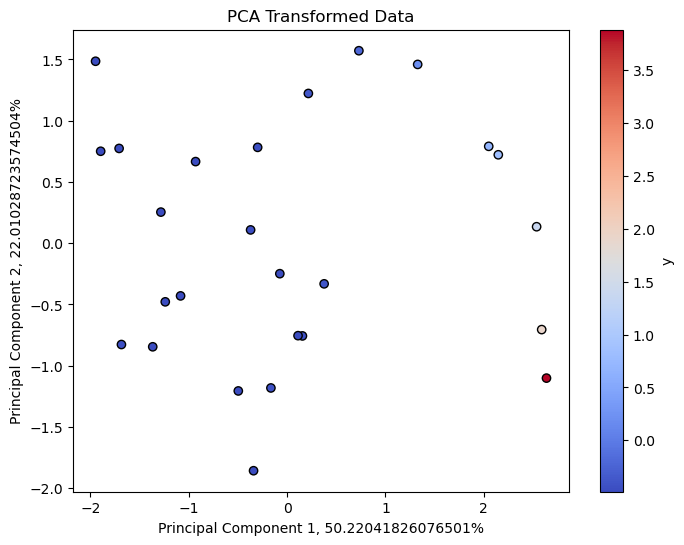

cutoff for high values 0.8333186136697832
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]


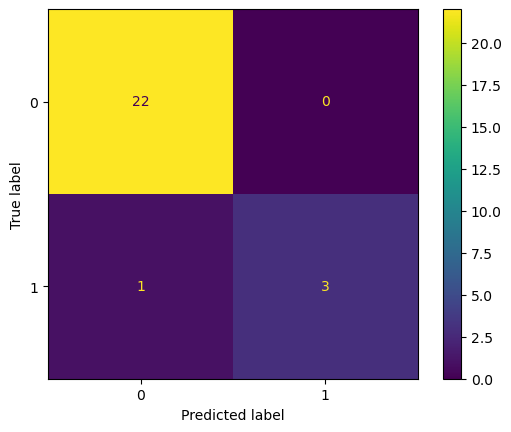

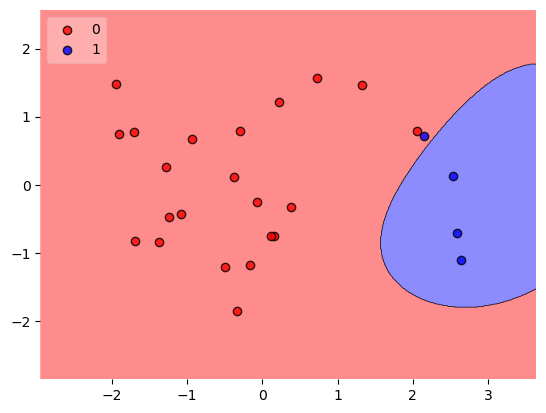

{'UCB': array([[1.11880018, 0.97590634, 0.47764256, 1.30246406]]), 'EI': array([[1.11880018, 0.97590634, 0.47764256, 1.30246406]]), 'PI': array([[1.11880018, 0.97590634, 0.47764256, 1.30246406]])}
previous point tried  [0.920526 1.089698 0.540378 1.339337]
previous output 16822.325905059733, max output 16822.325905059733
(26,)
scaled outs  [ 1.03559383  0.22837232 -0.52438372 -0.30267888  0.84836492  0.16796601
  0.1895638  -0.56044396 -1.98833747  0.06689048  0.33450097 -0.91599592
 -0.44400036 -0.01056938 -1.0882048  -0.57382094  0.09110497  0.67489927
 -1.31186403 -0.64600207 -2.12607392  1.0677464   1.65972837  1.62754723
  1.25166619  1.24843067]
raw outs [-0.71426495 -1.20995524 -1.67219994 -1.53605771 -0.82923655 -1.24704893
 -1.23378638 -1.69434344 -2.57116963 -1.30911635 -1.14478485 -1.91267714
 -1.62283895 -1.35668211 -2.0184254  -1.70255784 -1.29424696 -0.93575656
 -2.15576776 -1.74688209 -2.65574942 -0.69452102 -0.33100282 -0.35076428
 -0.58158145 -0.58356828]
Function 6 an

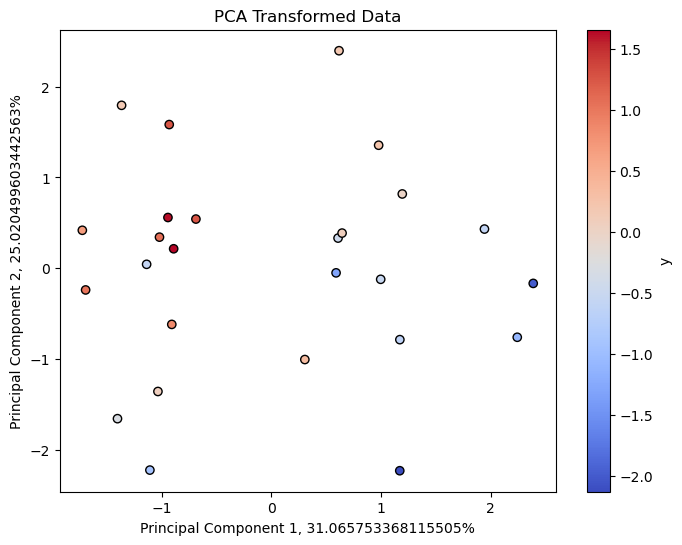

cutoff for high values 1.2484306720679261
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]


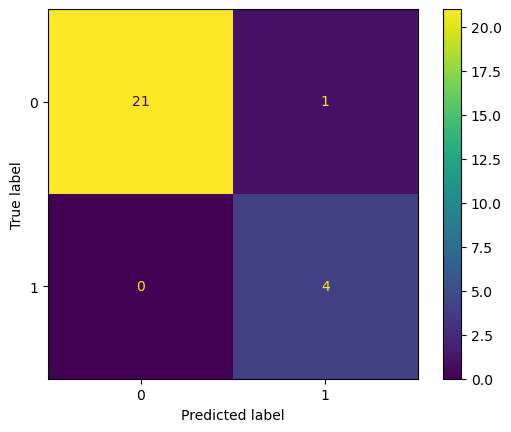

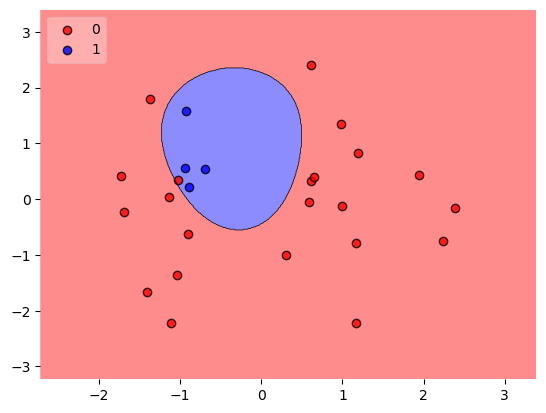

{'UCB': array([[0.58609758, 0.55119445, 0.57973472, 0.86485397, 0.1128134 ]]), 'EI': array([[0.58309351, 0.56162251, 0.59213621, 0.89105505, 0.09020612]]), 'PI': array([[0.58309351, 0.56162251, 0.59213621, 0.89105505, 0.09020612]])}
previous point tried  [0.564118 0.543044 0.545076 0.75768  0.227387]
previous output -0.583568282382558, max output -0.33100281642937823
(36,)
scaled outs  [ 0.62463278  0.52818899 -0.75662084 -0.63185121 -0.14217134 -0.58019902
  2.38445974 -0.55960877 -0.73263379 -0.69631587 -0.60387115 -0.2965964
 -0.7535609  -0.15292298  0.6410451  -0.73974084 -0.1379005  -0.61949726
 -0.67652384 -0.76773181 -0.73184827 -0.75774821 -0.54141744  0.32604964
  0.78824838  0.42106359 -0.76524199 -0.76673018 -0.72459769 -0.55320797
 -0.68988499  2.1991288   2.60943564  2.3896929   1.12718181  0.33929592]
raw outs [0.6044327  0.56275307 0.00750324 0.0614243  0.2730468  0.08374657
 1.3649683  0.09264495 0.0178696  0.03356494 0.0735163  0.2063097
 0.00882563 0.26840032 0.611525

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 7 analysis
(36, 2)
[[ 0.63458954 -0.42872413 -0.11502187  0.0132989  -0.2065615  -0.59784379]
 [ 0.22613161  0.32571549 -0.62865322 -0.11666251  0.65109779 -0.10015273]]
Explained variance: [0.27086291 0.23226535]
Cumulative: [0.27086291 0.50312826]


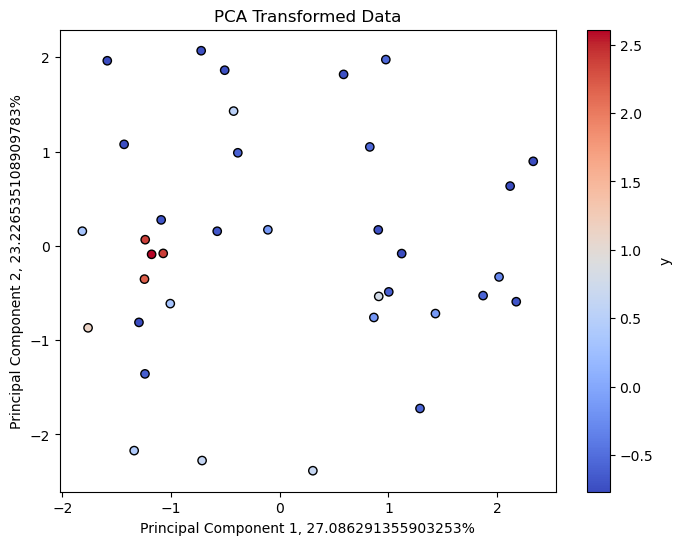

cutoff for high values 1.127181809113012
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0]


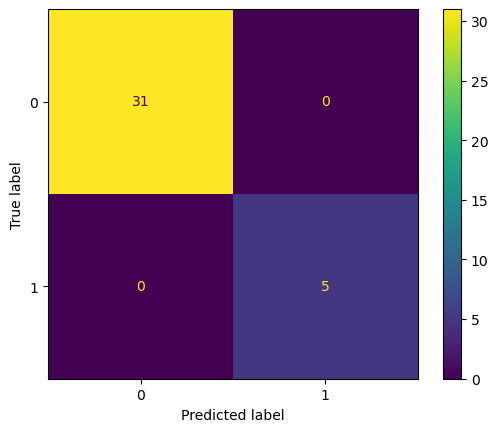

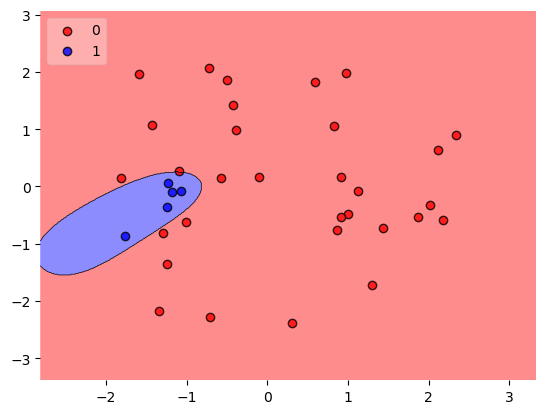

{'UCB': array([[-0.03069214,  0.52266134,  0.6596271 ,  0.49377156,  0.35177166,
         0.84072968]]), 'EI': array([[0.18924554, 0.49781209, 0.49836722, 0.47020759, 0.44213358,
        0.69214627]]), 'PI': array([[0.18924554, 0.49781209, 0.49836722, 0.47020759, 0.44213358,
        0.69214627]])}
previous point tried  [0.00358  0.569264 0.351724 0.304343 0.559632 0.82176 ]
previous output 0.4811200949987704, max output 1.4621950122984007
(46,)
scaled outs  [-0.59625745 -0.97226796  0.41737266  0.24969529  0.55749272  0.49598381
 -0.66437666 -0.69071456 -0.06194744 -2.32251974 -0.16068999 -1.17603505
  0.91147114 -0.61502311  1.50576637  0.13118118 -0.85148725 -1.19899092
 -0.56279058  0.9463696  -0.6801825  -2.08470347  1.06922173  0.75953985
 -1.50096935  0.77214056  1.2628533  -1.0844336   0.01864317 -0.31565746
 -0.09454761  0.38132631  0.24401404 -0.86884689 -1.54813119  0.43022955
 -0.04301776 -0.53686778 -0.56006772  1.10874957  1.30122112  0.61162292
  1.79698434  1.74681388  0

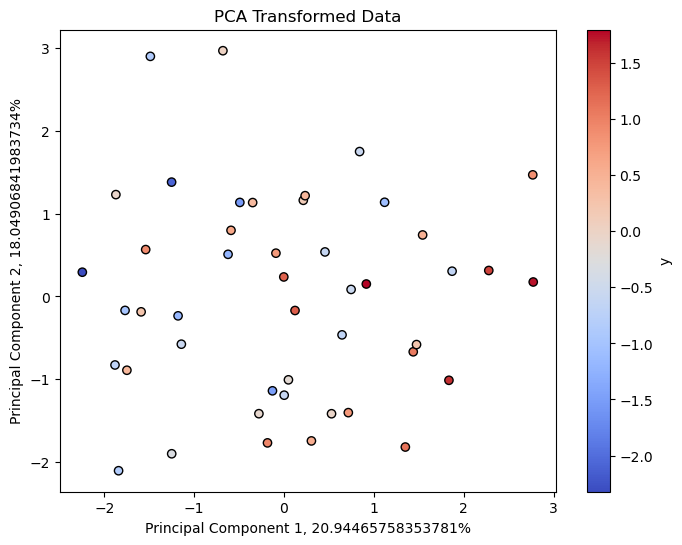

cutoff for high values 1.2628532985784224
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1]


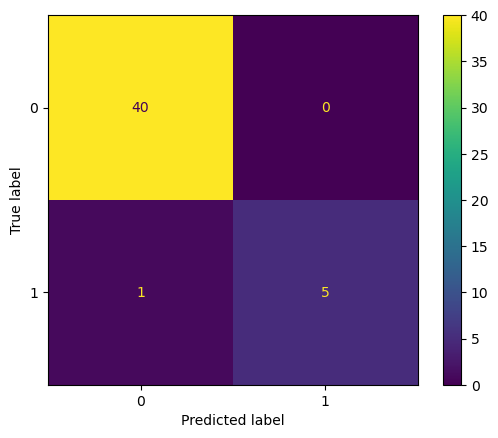

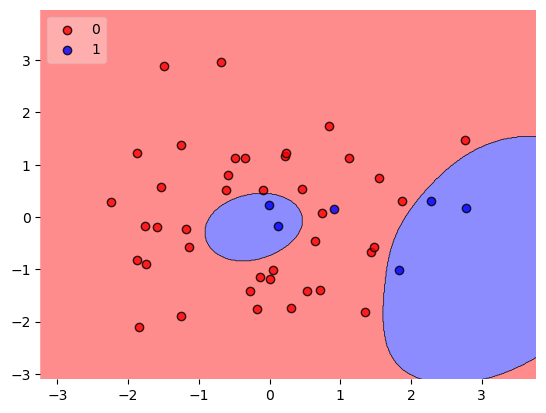

{'UCB': array([[ 0.29294485, -0.06061969,  0.22311666,  0.63161556,  0.53457851,
         0.61306759,  0.4048565 ,  0.99750701]]), 'EI': array([[ 0.13234034, -0.11972133,  0.33909383,  0.74991982,  0.34791812,
         0.45748051,  0.27447558,  1.05973767]]), 'PI': array([[ 0.13234034, -0.11972133,  0.33909383,  0.74991982,  0.34791812,
         0.45748051,  0.27447558,  1.05973767]])}
previous point tried  [0.009136 0.029457 0.227666 0.424728 0.406422 0.522447 0.399105 0.746412]
previous output 9.7054804972316, max output 9.9032406274175


In [24]:

sample_size=int(1e6)
for k in range(1,9): #9
    
    ins_raw = np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7/week_7_data/function_{k}/inputs.npy"
    )
    outs_raw=np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_7/week_7_data/function_{k}/outputs.npy"
    )
    print(outs_raw.shape)

    scaler=MinMaxScaler()   #StandardScaler()

    input_scaler = StandardScaler()
    output_scaler = StandardScaler()
    # input_scaler = MinMaxScaler()
    # output_scaler = MinMaxScaler()

    ins = input_scaler.fit_transform(ins_raw)
    outs = output_scaler.fit_transform(outs_raw.reshape(-1, 1)).ravel()
    #outs=outs_raw
    print("scaled outs ", outs)
    print("raw outs", outs_raw)
    
    
    

    
    # train GPR on data 
    in_cols=ins.shape[1]
    post_mean, post_std, sample_ins, model_GPR= GPR_with_learned_hyperparameters(
    ins,
    outs,
    sample_size,
    in_cols,
    initial_length_scale=0.5,
    initial_noise=1e-4,
    n_restarts=10)

    X=pd.DataFrame(ins)
    #y=pd.DataFrame(outs)

    y = pd.DataFrame({"Outputs": outs})

    
    
    #print(y.columns)

    

    print(f"Function {k} analysis")

    
    def conduct_PCA_homemade(X,y): # written by me not chat gpt 

        # make sure inputs are scaled  before 

        # standardise the data 
        #scaler=StandardScaler() # mean 0 and sd 1 , treating all features equally 
        X_scaled=X

        pca= PCA(n_components=2) # reduces the data to 2 components that explain most of the variance
        X_pca=pca.fit_transform(X_scaled)
        print(X_pca.shape)
        print(pca.components_)
        print("Explained variance:", pca.explained_variance_ratio_)
        print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))
       

        plt.figure(figsize=(8,6))
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y['Outputs'], cmap='coolwarm', edgecolor='k')
        plt.xlabel(f"Principal Component 1, { pca.explained_variance_ratio_[0]*100}%")
        plt.ylabel(f"Principal Component 2, { pca.explained_variance_ratio_[1]*100}%")
        plt.title("PCA Transformed Data")
        plt.colorbar(label="y")
        plt.show()

        return X_pca , pca #,scaler 
    

    X_pca, pca_model  =conduct_PCA_homemade(X,y)

    
    # sort data and take top 20% as the bound of the cutoff 
    def sort_data_take_x_percent_top_values(y,top_prcnt):
        if top_prcnt >=1:
            raise ValueError("percentages must be less than 100")
        sorted_y= y.sort_values(by='Outputs',ascending=False )
        #print(sorted_y)
        y_len=len(y)
        idx_x_percent= int(np.ceil(len(y)*top_prcnt))+1
        #print("length y",y_len)
        top_xprcnt_y=sorted_y.iloc[:idx_x_percent]
        print(top_xprcnt_y)
        exp_cutoff= top_xprcnt_y['Outputs'].iloc[-1]
        print(exp_cutoff)

        return exp_cutoff 
        

    sorted_y = y.sort_values(by="Outputs", ascending=False)
    idx_x_percent = int(np.ceil(len(y) * 0.1)) + 1
    top_10prcnt_y = sorted_y.iloc[:idx_x_percent]
    exp_cutoff = top_10prcnt_y["Outputs"].iloc[-1]
    y_labels = [1 if x >= exp_cutoff else 0 for x in y["Outputs"]]
    print("cutoff for high values",exp_cutoff)

    def apply_SVM_only_sample_success_regions(X_pca,y, exp_cutoff):
        # label data based on some inequality calling the bound exp_cutoff

        y_labels=[1 if x>=exp_cutoff else 0 for x in y["Outputs"]]
        print(y_labels)
        # could implement k-fold cross validation to check the model performs well on unseen data , thus validating choice for C, though the data is very snmall
        clf = svm.SVC(kernel = 'rbf', C=50)
        clf.fit(X_pca, y_labels)
        cm = confusion_matrix(y_labels, clf.predict(X_pca))
        cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_labels))
        cmd.plot()
        plt.show()

        plot_decision_regions(X_pca, np.array(y_labels).astype('int'), clf=clf, legend=2, colors = "red,blue", markers= "o");
        ax=plt.gca()
        plt.show()

        return clf 


    y_labels=[1 if x>=exp_cutoff else 0 for x in y["Outputs"]]
    print(y_labels)
    # could implement k-fold cross validation to check the model performs well on unseen data , thus validating choice for C, though the data is very snmall
    clf = svm.SVC(kernel = 'rbf', C=50)
    clf.fit(X_pca, y_labels)
    cm = confusion_matrix(y_labels, clf.predict(X_pca))
    cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y_labels))
    cmd.plot()
    plt.show()

    plot_decision_regions(X_pca, np.array(y_labels).astype('int'), clf=clf, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca()
    plt.show()


    # get decision boundary function , if f(z)>0 positive then the points are in the region. 

    def generating_decision_region_coordinates_monte_carlo(clf,X_pca,sample_size_decision_region=int(50e4)):

        array_size=0
        #sample_size_decision_region=int(50000)
        decision_region_sample_ins=np.zeros(( sample_size_decision_region,2))
        while array_size< sample_size_decision_region:
        
            # generate random numbers over whole decision region in PCA space 
            x1_min, x1_max = X_pca[:, 0].min(), X_pca[:, 0].max()
            x2_min, x2_max = X_pca[:, 1].min(), X_pca[:, 1].max()

            z = np.array([[
                np.random.uniform(x1_min, x1_max),
                np.random.uniform(x2_min, x2_max)
            ]])

            # evaluate coordinates against decision bound 
            decision= clf.decision_function(z)

            if decision>0:
                decision_region_sample_ins[array_size]=z 
                array_size+=1
                #print(array_size)
            else:
                continue 

        return decision_region_sample_ins




    array_size=0
    sample_size_decision_region=int(5000)
    decision_region_sample_ins=np.zeros(( sample_size_decision_region,2))
    while array_size< sample_size_decision_region:
     
        # generate random numbers over whole decision region in PCA space 
        x1_min, x1_max = X_pca[:, 0].min(), X_pca[:, 0].max()
        x2_min, x2_max = X_pca[:, 1].min(), X_pca[:, 1].max()

        z = np.array([[
            np.random.uniform(x1_min, x1_max),
            np.random.uniform(x2_min, x2_max)
        ]])

        # evaluate coordinates against decision bound 
        decision= clf.decision_function(z)

        if decision>0:
            decision_region_sample_ins[array_size]=z 
            array_size+=1
            #print(array_size)
        else:
            continue 


    # invert coordinates from PCA plane to scaled space 

    decision_bound_inputs=pca_model.inverse_transform(decision_region_sample_ins)

    # # invert coordinates from standard scaling mean=0 , sd=1

    # decision_bound_inputs= scaler.inverse_transform(decision_bound_inputs)

    # use GPR trained on original inputs to predict values 

    post_mean_dec, post_std_dec = model_GPR.predict(decision_bound_inputs, return_std=True)


    # applying acquisition functions to new points 

    f_best = np.max(outs)
    Beta = 1 #used to be 5 , switching to 1 to balance exploration and explotation 
    Xi = 0.05

    x_next_UCB = acquisition_UCB(Beta,post_mean_dec, post_std_dec, decision_bound_inputs)


    ei = accquisition_expected_improvement(post_mean_dec, post_std_dec, f_best)
    x_next_EI = decision_bound_inputs[np.argmax(ei)]

    pi = accquisition_prob_improve(post_mean_dec, post_std_dec, f_best, xi=Xi)
    x_next_PI = decision_bound_inputs[np.argmax(pi)]

    next_points = {
    "UCB": input_scaler.inverse_transform(np.round(x_next_UCB, 6).reshape(1, -1)),
    "EI": input_scaler.inverse_transform(np.round(x_next_EI, 6).reshape(1, -1)),
    "PI": input_scaler.inverse_transform(np.round(x_next_PI, 6).reshape(1, -1)),
}
    # function
    print(next_points)
    print("previous point tried ", ins_raw[-1])
    print(f"previous output {outs_raw[-1]}, max output {np.max(outs_raw)}" )

### Possible improvements and extensions

- Use **adaptive output transformations** depending on the function, for example raw outputs, standardisation, or `arcsinh` / signed-log transforms for extreme dynamic ranges.
- Replace the isotropic RBF kernel with an **ARD kernel**, allowing a separate length scale in each input dimension.
- Compare **RBF and Matérn kernels** to test whether a less smooth prior improves surrogate performance.
- Use **Expected Improvement (EI)** as the main acquisition function, while keeping UCB and PI as comparison baselines.
- Make the exploration parameters **adaptive across rounds**, for example reducing \(\beta\) or \(\xi\) as more data is collected.
- Add a **diversity penalty** or minimum-distance rule to avoid proposing points too close to existing observations.
- Replace purely uniform random candidate generation with **Sobol sequences** or **Latin hypercube sampling** for better coverage of the search space.
- Optimise the acquisition function more directly, for example using **multi-start local optimisation** after an initial Monte Carlo screening step.
- Improve the PCA/SVM stage by using **adaptive thresholds** or probabilistic success labels rather than a fixed top-10\% cutoff.
- Test whether the PCA/SVM filtering genuinely helps by running **ablation studies** comparing the full method against simpler GP-only BO baselines.
- Combine the classifier and acquisition function into a single **hybrid acquisition rule**, for example
  $$
  a_{\mathrm{hybrid}}(\mathbf{x}) = \mathrm{EI}(\mathbf{x})\,p(\text{promising}\mid \mathbf{x}),
  $$
  so that search is guided by both surrogate uncertainty and a learned promising-region score.
- Track additional diagnostics such as best value so far, uncertainty at the selected point, and distance to previous samples, to better evaluate optimisation behaviour across rounds.
- look at bounds of input functions, seems like only positive inputs are allowed, should probably constrain the model for this 
- could also do with looking at the black box descriptions, check that we are using the right form of maximisation 



%%Ablation study of the PCA/SVM search.